In [1]:
import torch
import matplotlib.pyplot as plt

from mropes.position import get_positional_encoding

In [10]:
max_dist = 128
dim = 192
base = 10000
n_axes = 3

axes_shape = [1] * n_axes

fig = plt.figure(figsize=(10, 5))

<Figure size 1000x500 with 0 Axes>

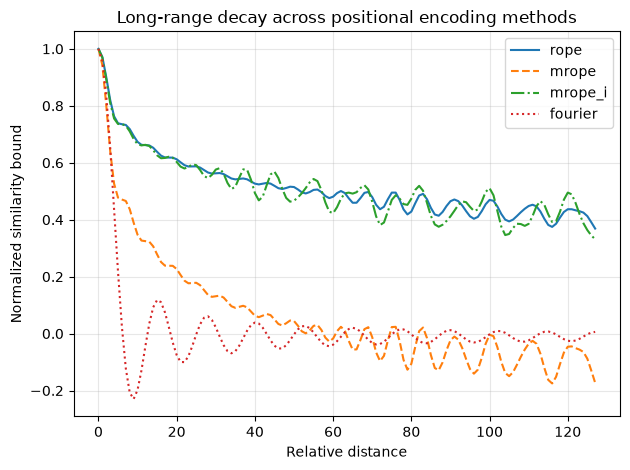

In [9]:
# --- RoPE: 1D, integer positions ---
rope = get_positional_encoding("rope", dim=dim, base=base)
x = torch.zeros(1, max_dist, dim)
ang = rope(x, return_theta=True)  # (max_dist, d//2)
decay = ang.cos().mean(dim=-1)
plt.plot(decay.detach().numpy(), label="rope")

# --- MRoPE: contiguous channel-split baseline ---
# second axis fixed at size 1 so only axis 0 actually varies
mrope = get_positional_encoding("mrope", dim=dim, base=base)
x = torch.zeros(1, max_dist, 1, dim)
ang = mrope(x, return_theta=True)  # (n_axes, seq, n_pairs_per_axis)
decay = ang.cos().mean(dim=-1)
plt.plot(
    decay[0].detach().numpy(),
    label="mrope",
    linestyle="--",
)

# --- MRoPEInterleave: round-robin split ---
mrope_i = get_positional_encoding("mrope_i", dim=dim, base=base)
x = torch.zeros(1, max_dist, 1, dim)
ang = mrope_i(x, return_theta=True)
decay = ang.cos().mean(dim=-1)
plt.plot(
    decay[0].detach().numpy(), label="mrope_i", linestyle="-."
)

# --- FourierPE ---
fourier = get_positional_encoding("fourier", n_bands=dim // 2, dim=dim)
x = torch.zeros(1, max_dist, 1, dim)
freq = fourier(x, return_frequency=True)  # (n_axes, *axes, n_bands)
decay = freq.cos().mean(dim=-1)
plt.plot(
    decay[0, :, 0].detach().numpy(), label="fourier", linestyle=":"
)

plt.xlabel("Relative distance")
plt.ylabel("Normalized similarity bound")
plt.title("Long-range decay across positional encoding methods")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

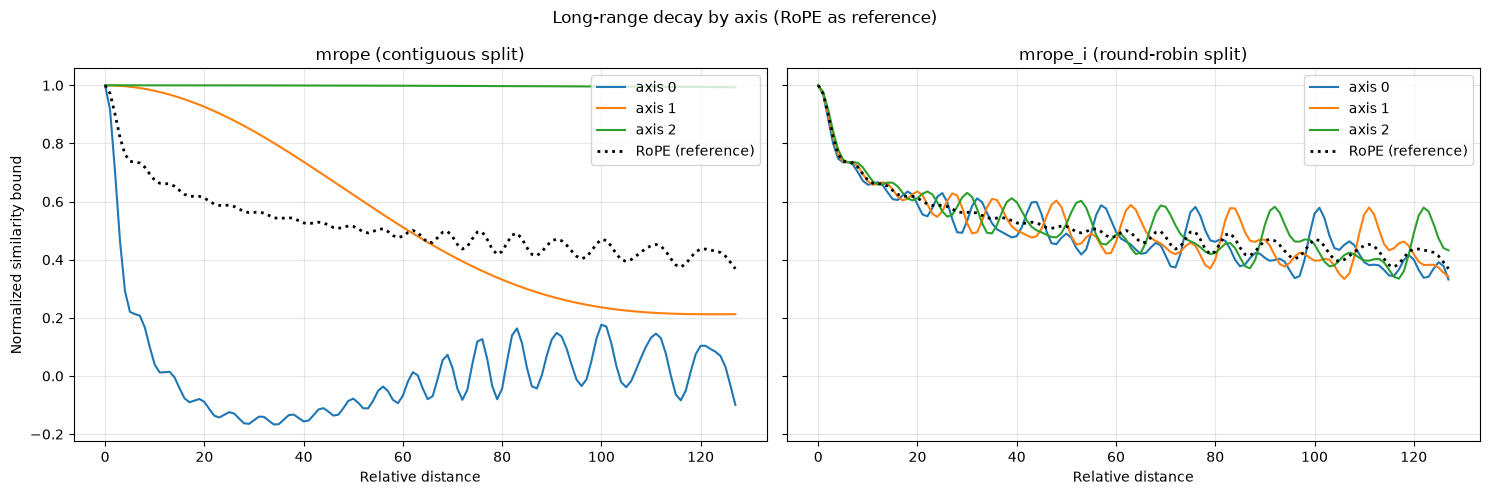

In [18]:
# --- reference RoPE decay (single axis, full spectrum) ---
x_1d = torch.zeros(1, max_dist, dim)
theta_rope = rope(x_1d, return_theta=True)
decay_rope = theta_rope.cos().mean(dim=-1)

fig, (ax_mrope, ax_mrope_i) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for axis_idx in range(n_axes):
    shape = list(axes_shape)
    shape[axis_idx] = max_dist

    x = torch.zeros(1, *shape, dim)

    theta_mrope = mrope(x, return_theta=True)  # (n_axes, seq, k)
    theta_mrope_i = mrope_i(x, return_theta=True)  # (n_axes, seq, k)

    decay_mrope = theta_mrope[axis_idx].cos().mean(dim=-1)
    decay_mrope_i = theta_mrope_i[axis_idx].cos().mean(dim=-1)

    ax_mrope.plot(decay_mrope.detach().numpy(), label=f"axis {axis_idx}")
    ax_mrope_i.plot(decay_mrope_i.detach().numpy(), label=f"axis {axis_idx}")

ax_mrope.plot(
    decay_rope.detach().numpy(),
    label="RoPE (reference)",
    color="black",
    linestyle=":",
    linewidth=2,
)
ax_mrope_i.plot(
    decay_rope.detach().numpy(),
    label="RoPE (reference)",
    color="black",
    linestyle=":",
    linewidth=2,
)

ax_mrope.set_title("mrope (contiguous split)")
ax_mrope.set_xlabel("Relative distance")
ax_mrope.set_ylabel("Normalized similarity bound")
ax_mrope.grid(alpha=0.3)
ax_mrope.legend(loc='upper right')

ax_mrope_i.set_title("mrope_i (round-robin split)")
ax_mrope_i.set_xlabel("Relative distance")
ax_mrope_i.grid(alpha=0.3)
ax_mrope_i.legend(loc='upper right')

fig.suptitle("Long-range decay by axis (RoPE as reference)")
plt.tight_layout()